# Decision Tree Model - Visa Denial Prediction (IT25101547)

This notebook trains and compares Decision Tree models to predict whether a visa application is denied. It uses the preprocessed handover file `results/outputs/final_processed.csv.gz`, which has 283,879 training rows and 70,970 test rows with 25 features. The target column is `denied` (1 = denied, 0 = not denied). Only 6.9% of applications are denied, so the dataset is highly imbalanced.

**Evaluation rules (shared by all group models):** every variety is compared with 5-fold stratified cross-validation on the **training rows only**; the best variety is chosen by CV PR-AUC; the decision threshold comes from out-of-fold predictions; the **test set is used once**, at the end.

## 1. Imports
This cell imports the libraries used for loading the data, training the Decision Tree models and evaluating them.

In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, make_scorer, precision_recall_curve,
                             classification_report, ConfusionMatrixDisplay)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

## 2. Load the Preprocessed Dataset
This cell loads the cleaned and scaled dataset from the preprocessing stage. The data is divided into training and test sets using the existing `split` column. The `denied` column is the target, and the remaining 25 columns are the features. The output shows 283,879 training rows and 70,970 test rows, and that only 6.9% of applications are denied, so the dataset is highly imbalanced.

In [2]:
PATH = '../results/outputs/final_processed.csv.gz'
if not os.path.exists(PATH):                 # also works when run from the repo root
    PATH = 'results/outputs/final_processed.csv.gz'
df = pd.read_csv(PATH, compression='gzip')

train = df[df['split'] == 'train']
test = df[df['split'] == 'test']

X_train = train.drop(columns=['denied', 'split'])
y_train = train['denied']
X_test = test.drop(columns=['denied', 'split'])
y_test = test['denied']

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(283879, 25) (70970, 25)
denied
0    0.93089
1    0.06911
Name: proportion, dtype: float64


## 3. Evaluation Function (5-fold cross-validation on the training rows)
This cell defines a helper function that scores a model variety with **5-fold stratified cross-validation on the training rows only** (the shared `StratifiedKFold(5, shuffle=True, random_state=42)` used by every group member). For each metric it stores the mean and the standard deviation over the 5 folds: Accuracy, Precision, Recall, F1, ROC-AUC and PR-AUC. The test set is **not** used here, so choosing between varieties can't leak test information. Because the data is imbalanced, PR-AUC, F1 and Recall are more meaningful than Accuracy.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = {'Accuracy': 'accuracy', 'Precision': make_scorer(precision_score, zero_division=0),
           'Recall': 'recall', 'F1': 'f1', 'ROC-AUC': 'roc_auc', 'PR-AUC': 'average_precision'}
results, models = [], {}

def evaluate(name, model):
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    row = {'Model': name}
    for m in SCORING:
        row[m] = scores[f'test_{m}'].mean()
        row[f'{m} std'] = scores[f'test_{m}'].std()
    results.append(row)
    models[name] = model
    print(f"{name}: CV PR-AUC {row['PR-AUC']:.4f} ± {row['PR-AUC std']:.4f} | F1 {row['F1']:.4f} | "
          f"Recall {row['Recall']:.4f} | Precision {row['Precision']:.4f}")
    return model

## 4. Model Varieties (Manual Tuning)
This cell scores four varieties of the Decision Tree with 5-fold CV:
1. Baseline: default settings, the tree grows to full depth.
2. max_depth=10: the depth is limited to reduce overfitting.
3. Balanced: `class_weight='balanced'` gives more weight to the denied class.
4. Undersampled: inside each training fold, all denied rows are kept and an equal number of not-denied rows is sampled (`RandomUnderSampler` in an `imblearn` Pipeline, so the validation fold is never undersampled).

**CV results:** the fully grown baseline overfits and ranks denials poorly (PR-AUC 0.194). Limiting the depth to 10 doubles PR-AUC to 0.388 and gives high precision (0.838) but low recall (0.189). Balancing the classes (weights 0.387, undersampling 0.281) raises recall to about 0.70 but drops precision to about 0.17, which is the usual precision-recall trade-off.

In [4]:
evaluate('DT Baseline', DecisionTreeClassifier(random_state=42))

evaluate('DT max_depth=10', DecisionTreeClassifier(max_depth=10, random_state=42))

evaluate('DT Balanced depth=10', DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42))

evaluate('DT Undersampled depth=10',
         ImbPipeline([('under', RandomUnderSampler(random_state=42)),
                      ('dt', DecisionTreeClassifier(max_depth=10, random_state=42))]))

pd.DataFrame(results)[['Model', 'PR-AUC', 'PR-AUC std', 'ROC-AUC', 'F1', 'Precision', 'Recall', 'Accuracy']].round(4)

DT Baseline: CV PR-AUC 0.1938 ± 0.0025 | F1 0.3722 | Recall 0.3698 | Precision 0.3746


DT max_depth=10: CV PR-AUC 0.3881 ± 0.0112 | F1 0.3078 | Recall 0.1885 | Precision 0.8379


DT Balanced depth=10: CV PR-AUC 0.3870 ± 0.0137 | F1 0.2742 | Recall 0.7041 | Precision 0.1704


DT Undersampled depth=10: CV PR-AUC 0.2812 ± 0.0143 | F1 0.2639 | Recall 0.7182 | Precision 0.1617


,Model,PR-AUC,PR-AUC std,ROC-AUC,F1,Precision,Recall,Accuracy
0,DT Baseline,0.1938,0.0025,0.6856,0.3722,0.3746,0.3698,0.9138
1,DT max_depth=10,0.3881,0.0112,0.8010,0.3078,0.8379,0.1885,0.9414
2,DT Balanced depth=10,0.3870,0.0137,0.8032,0.2742,0.1704,0.7041,0.7418
3,DT Undersampled depth=10,0.2812,0.0143,0.7970,0.2639,0.1617,0.7182,0.7227


## 5. Hyperparameter Tuning with GridSearchCV

This cell searches 60 combinations of `criterion`, `max_depth`, `min_samples_leaf` and `class_weight` using 5-fold stratified cross validation (300 fits in total). Stratified folds keep the same class ratio in every fold. **PR-AUC** (`average_precision`) is used to select the best combination, as agreed for all group models, because it measures how well denied applications are ranked above approved ones regardless of the threshold.

**Result:** the best combination is `criterion='gini'`, `max_depth=15`, `min_samples_leaf=20`, `class_weight=None`, with a CV PR-AUC of **0.425 ± 0.010**. Requiring at least 20 rows per leaf stops the tree from memorising single applications, which is why it ranks denials much better than the fully grown baseline. Its training PR-AUC (0.491) is somewhat higher than the CV score, so a small amount of overfitting remains.

In [5]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 20, 100],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,
                    scoring='average_precision', cv=cv, n_jobs=-1, verbose=1, return_train_score=True)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(f'Best CV PR-AUC: {grid.best_score_:.4f}')
grid_table = pd.DataFrame(grid.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']]
grid_table.sort_values('rank_test_score').head(10).round(4)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


{'class_weight': None, 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 20}
Best CV PR-AUC: 0.4249


,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
7,"{'class_weight': None, 'criterion': 'gini', 'm...",0.4249,0.0095,0.4912,1
22,"{'class_weight': None, 'criterion': 'entropy',...",0.4203,0.0092,0.4944,2
10,"{'class_weight': None, 'criterion': 'gini', 'm...",0.4180,0.0092,0.5393,3
25,"{'class_weight': None, 'criterion': 'entropy',...",0.4146,0.0101,0.5418,4
52,"{'class_weight': 'balanced', 'criterion': 'ent...",0.4142,0.0082,0.4929,5
37,"{'class_weight': 'balanced', 'criterion': 'gin...",0.4130,0.0098,0.4971,6
13,"{'class_weight': None, 'criterion': 'gini', 'm...",0.4125,0.0089,0.5661,7
55,"{'class_weight': 'balanced', 'criterion': 'ent...",0.4124,0.0080,0.5423,8
40,"{'class_weight': 'balanced', 'criterion': 'gin...",0.4117,0.0086,0.5456,9
28,"{'class_weight': None, 'criterion': 'entropy',...",0.4090,0.0115,0.5708,10


## 6. Final Tuned Model and Comparison Table

This cell adds the GridSearchCV best settings as a fifth variety and shows the 5-fold CV comparison of all five varieties (mean over the folds; the `std` columns show how stable each result is).

**Result:** the tuned tree has the best CV PR-AUC (0.425 ± 0.010) and ROC-AUC (0.807). At the default 0.5 threshold it is precise (0.768) but cautious (recall 0.231); the threshold is tuned in section 8.

In [6]:
evaluate('DT GridSearch Best', DecisionTreeClassifier(**grid.best_params_, random_state=42))

res = pd.DataFrame(results).round(4)
res[['Model', 'PR-AUC', 'PR-AUC std', 'ROC-AUC', 'F1', 'Precision', 'Recall', 'Accuracy']]

DT GridSearch Best: CV PR-AUC 0.4249 ± 0.0095 | F1 0.3548 | Recall 0.2307 | Precision 0.7679


,Model,PR-AUC,PR-AUC std,ROC-AUC,F1,Precision,Recall,Accuracy
0,DT Baseline,0.1938,0.0025,0.6856,0.3722,0.3746,0.3698,0.9138
1,DT max_depth=10,0.3881,0.0112,0.8010,0.3078,0.8379,0.1885,0.9414
2,DT Balanced depth=10,0.3870,0.0137,0.8032,0.2742,0.1704,0.7041,0.7418
3,DT Undersampled depth=10,0.2812,0.0143,0.7970,0.2639,0.1617,0.7182,0.7227
4,DT GridSearch Best,0.4249,0.0095,0.8074,0.3548,0.7679,0.2307,0.9420


## 7. Comparison Chart
This cell plots the CV Precision, Recall, F1 and PR-AUC for all five varieties as a bar chart, which makes the precision and recall trade-off between the varieties easy to see.

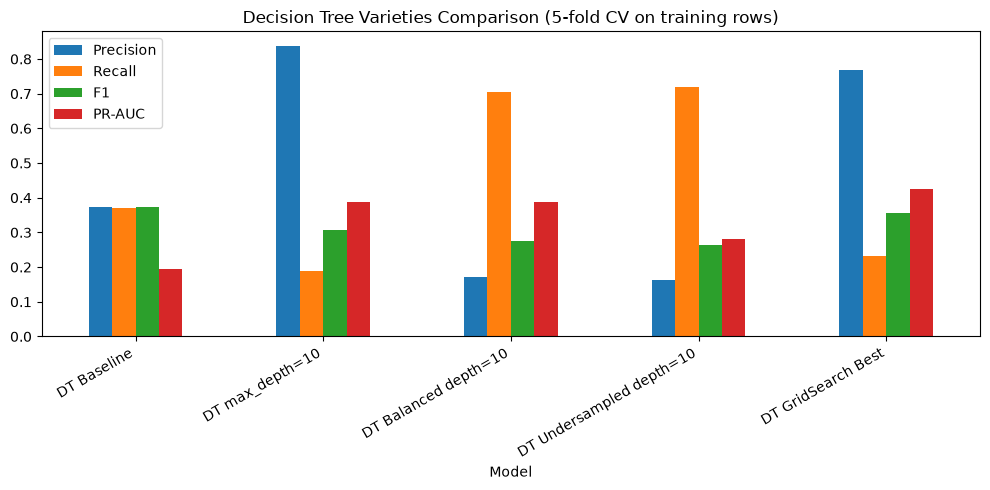

In [7]:
res.set_index('Model')[['Precision', 'Recall', 'F1', 'PR-AUC']].plot(kind='bar', figsize=(10, 5))
plt.title('Decision Tree Varieties Comparison (5-fold CV on training rows)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. Best Variety, Threshold, and the One Test Evaluation
1. **Choose the variety by CV only:** the highest mean CV PR-AUC. Varieties within one standard deviation of it count as a tie, and then the tuned model (GridSearch Best) is preferred.
2. **Threshold:** the probability cut-off with the best F1 for the denied class, found from **out-of-fold** predictions on the training rows (each row predicted by a model that never saw it).
3. **Test once:** the chosen model is fitted on all training rows and evaluated on the 70,970 test rows a single time. The classification report and confusion matrix show the result for each class.

**Result:** GridSearch Best is selected (no other variety is within one standard deviation). The out-of-fold threshold is **0.251** (OOF F1 0.407 vs 0.359 at 0.5). On the test set (used once): **PR-AUC 0.416**, ROC-AUC 0.809, F1 (Denied) 0.393, precision 0.492, recall 0.327, accuracy 0.930 (the always-approve baseline is 0.931). The test PR-AUC is close to the CV PR-AUC (0.425), so the model generalises.

Highest CV PR-AUC: DT GridSearch Best (0.4249 ± 0.0095) | tied: ['DT GridSearch Best']
Selected variety: DT GridSearch Best


Out-of-fold F1-optimal threshold: 0.251 (OOF F1 0.407; at 0.5: 0.359)


              precision    recall  f1-score   support

  Not Denied     0.9512    0.9749    0.9629     66065
      Denied     0.4917    0.3266    0.3925      4905

    accuracy                         0.9301     70970
   macro avg     0.7215    0.6508    0.6777     70970
weighted avg     0.9195    0.9301    0.9235     70970

Test PR-AUC 0.4162 | ROC-AUC 0.8088


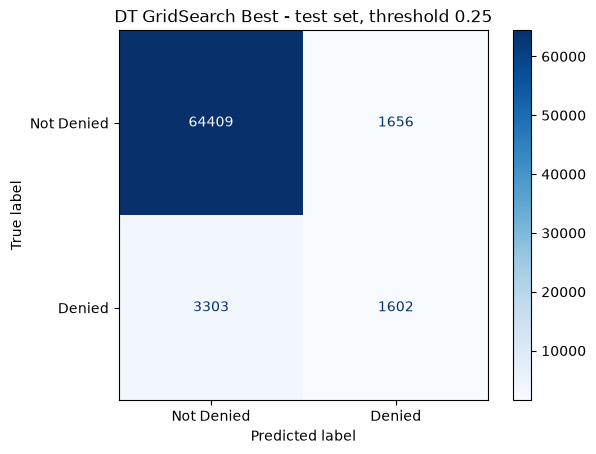

In [8]:
cand = res.sort_values('PR-AUC', ascending=False)
top = cand.iloc[0]
tied = cand[cand['PR-AUC'] >= top['PR-AUC'] - top['PR-AUC std']]['Model'].tolist()
best_name = 'DT GridSearch Best' if 'DT GridSearch Best' in tied else top['Model']
print(f"Highest CV PR-AUC: {top['Model']} ({top['PR-AUC']:.4f} ± {top['PR-AUC std']:.4f}) | tied: {tied}")
print('Selected variety:', best_name)

oof = cross_val_predict(models[best_name], X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
p, r, t = precision_recall_curve(y_train, oof)
f1s = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
THRESHOLD = float(t[np.argmax(f1s)])
print(f'Out-of-fold F1-optimal threshold: {THRESHOLD:.3f} (OOF F1 {f1s.max():.3f}; at 0.5: {f1_score(y_train, (oof >= 0.5).astype(int)):.3f})')

best = models[best_name].fit(X_train, y_train)
prob = best.predict_proba(X_test)[:, 1]
pred = (prob >= THRESHOLD).astype(int)
print(classification_report(y_test, pred, target_names=['Not Denied', 'Denied'], digits=4))
print(f'Test PR-AUC {average_precision_score(y_test, prob):.4f} | ROC-AUC {roc_auc_score(y_test, prob):.4f}')

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['Not Denied', 'Denied'], cmap='Blues')
plt.title(f'{best_name} - test set, threshold {THRESHOLD:.2f}')
plt.show()

## 9. Feature Importance and Tree Visualisation
This cell shows the 15 features that the tree used most when making decisions, and draws the top three levels of the tree. Feature importance shows how much a feature is used for splitting, not whether it increases or decreases the chance of denial.

`pwsrc_Unknown` is the feature most used by the tree (importance 0.27), followed by `wage_offer_annual` (0.24), `employer_filing_count_log` (0.13) and `employer_num_employees_log` (0.10). The first split in the tree is on `pwsrc_Unknown`: 1,597 of the 1,631 training applications with an unknown prevailing wage source are denied. The final tree has depth 15 and 1,428 leaves.

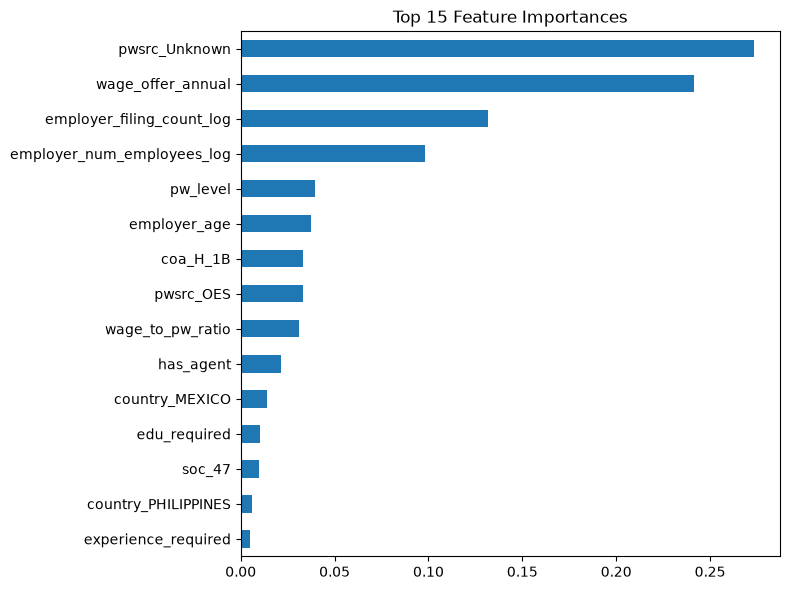

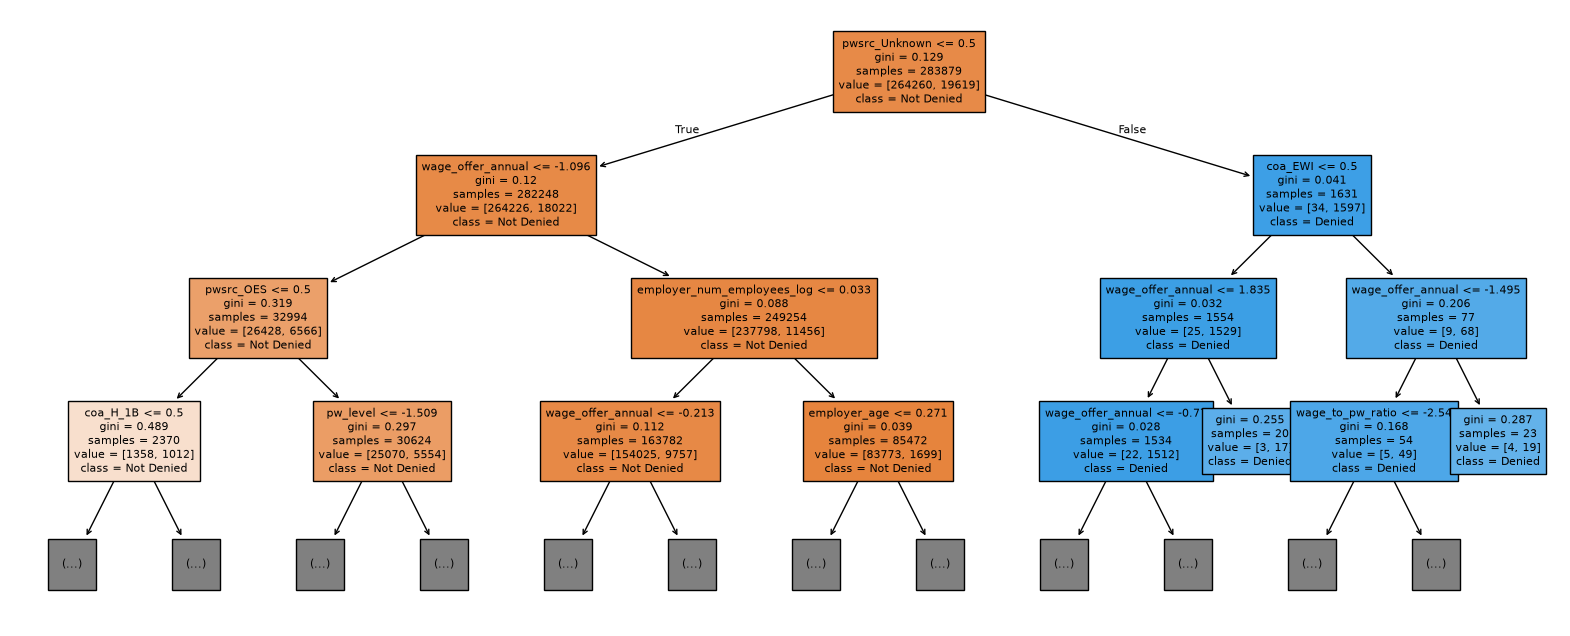

In [9]:
tree = best.named_steps['dt'] if hasattr(best, 'named_steps') else best
imp = pd.Series(tree.feature_importances_, index=X_train.columns).sort_values().tail(15)
imp.plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 8))
plot_tree(tree, max_depth=3, feature_names=list(X_train.columns), class_names=['Not Denied', 'Denied'],
          filled=True, fontsize=8)
plt.show()

## 10. Save Results
This cell saves everything to `results/models/IT25101547_DecisionTree/`:
- `cv_varieties.csv`: the 5-fold CV table of all varieties;
- `grid_search_results.csv`: all 60 GridSearchCV combinations;
- `test_metrics.json`: the final test result, using the same keys as the other members;
- `test_scores.csv.gz`: the predicted probability for every test row (used by `group_pipeline.ipynb` to recompute and compare all models with one common function);
- `model.joblib`: the fitted model, threshold and feature list.

In [10]:
MODEL_DIR = '../results/models/IT25101547_DecisionTree'
if not os.path.isdir('../results'):
    MODEL_DIR = 'results/models/IT25101547_DecisionTree'
os.makedirs(MODEL_DIR, exist_ok=True)
res.to_csv(os.path.join(MODEL_DIR, 'cv_varieties.csv'), index=False)
grid_table.sort_values('rank_test_score').to_csv(os.path.join(MODEL_DIR, 'grid_search_results.csv'), index=False)

row = res.set_index('Model').loc[best_name]
test_metrics = {
    'member': 'IT25101547', 'model': 'Decision Tree', 'variety': best_name, 'dataset': 'B',
    'params': {k: v for k, v in tree.get_params().items()
               if k in ('criterion', 'max_depth', 'min_samples_leaf', 'class_weight')},
    'threshold': round(THRESHOLD, 4),
    'cv_pr_auc_mean': round(float(row['PR-AUC']), 4), 'cv_pr_auc_std': round(float(row['PR-AUC std']), 4),
    'test_pr_auc': round(average_precision_score(y_test, prob), 4),
    'test_roc_auc': round(roc_auc_score(y_test, prob), 4),
    'test_f1_denied': round(f1_score(y_test, pred), 4),
    'test_precision_denied': round(precision_score(y_test, pred), 4),
    'test_recall_denied': round(recall_score(y_test, pred), 4),
    'test_accuracy': round(accuracy_score(y_test, pred), 4),
    'baseline_accuracy_always_approve': round(1 - float(y_test.mean()), 4),
}
with open(os.path.join(MODEL_DIR, 'test_metrics.json'), 'w') as f:
    json.dump(test_metrics, f, indent=2)
pd.DataFrame({'denied': y_test.to_numpy(), 'score': prob}).to_csv(
    os.path.join(MODEL_DIR, 'test_scores.csv.gz'), index=False, float_format='%.6g')
joblib.dump({'model': best, 'threshold': THRESHOLD, 'features': list(X_train.columns), 'variety': best_name},
            os.path.join(MODEL_DIR, 'model.joblib'))
print(json.dumps(test_metrics, indent=2))
print('Saved:', sorted(os.listdir(MODEL_DIR)))

{
  "member": "IT25101547",
  "model": "Decision Tree",
  "variety": "DT GridSearch Best",
  "dataset": "B",
  "params": {
    "class_weight": null,
    "criterion": "gini",
    "max_depth": 15,
    "min_samples_leaf": 20
  },
  "threshold": 0.2514,
  "cv_pr_auc_mean": 0.4249,
  "cv_pr_auc_std": 0.0095,
  "test_pr_auc": 0.4162,
  "test_roc_auc": 0.8088,
  "test_f1_denied": 0.3925,
  "test_precision_denied": 0.4917,
  "test_recall_denied": 0.3266,
  "test_accuracy": 0.9301,
  "baseline_accuracy_always_approve": 0.9309
}
Saved: ['cv_varieties.csv', 'grid_search_results.csv', 'model.joblib', 'test_metrics.json', 'test_scores.csv.gz']
